In [1]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
# 재현성 확보
def seed_setting(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
seed_setting(42)

In [4]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
device

device(type='cuda')

In [6]:
# 라벨: 1 : 정상/ 2~5 : 비정상
df1=pd.read_csv('./ECG5000.csv')
df1

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,1.0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,...,0.160348,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137
1,1.0,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,...,0.560327,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250
2,1.0,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,...,1.284825,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797
3,1.0,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,...,0.491173,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564
4,1.0,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,...,0.966606,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4.0,-1.122969,-2.252925,-2.867628,-3.358605,-3.167849,-2.638360,-1.664162,-0.935655,-0.866953,...,0.205543,-0.472419,-1.310147,-2.029521,-3.221294,-4.176790,-4.009720,-2.874136,-2.008369,-1.808334
4996,2.0,-0.547705,-1.889545,-2.839779,-3.457912,-3.929149,-3.966026,-3.492560,-2.695270,-1.849691,...,1.218185,1.258419,1.907530,2.280888,1.895242,1.437702,1.193433,1.261335,1.150449,0.804932
4997,2.0,-1.351779,-2.209006,-2.520225,-3.061475,-3.065141,-3.030739,-2.622720,-2.044092,-1.295874,...,-0.896575,-1.512234,-2.076075,-2.586042,-3.322799,-3.627311,-3.437038,-2.260023,-1.577823,-0.684531
4998,2.0,-1.124432,-1.905039,-2.192707,-2.904320,-2.900722,-2.761252,-2.569705,-2.043893,-1.490538,...,-2.495989,-2.821782,-3.268355,-3.634981,-3.168765,-2.245878,-1.262260,-0.443307,-0.559769,0.108568


In [7]:
df2=df1.add_prefix('c')
df2

,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,...,c131,c132,c133,c134,c135,c136,c137,c138,c139,c140
0,1.0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,...,0.160348,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137
1,1.0,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,...,0.560327,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250
2,1.0,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,...,1.284825,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797
3,1.0,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,...,0.491173,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564
4,1.0,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,...,0.966606,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4.0,-1.122969,-2.252925,-2.867628,-3.358605,-3.167849,-2.638360,-1.664162,-0.935655,-0.866953,...,0.205543,-0.472419,-1.310147,-2.029521,-3.221294,-4.176790,-4.009720,-2.874136,-2.008369,-1.808334
4996,2.0,-0.547705,-1.889545,-2.839779,-3.457912,-3.929149,-3.966026,-3.492560,-2.695270,-1.849691,...,1.218185,1.258419,1.907530,2.280888,1.895242,1.437702,1.193433,1.261335,1.150449,0.804932
4997,2.0,-1.351779,-2.209006,-2.520225,-3.061475,-3.065141,-3.030739,-2.622720,-2.044092,-1.295874,...,-0.896575,-1.512234,-2.076075,-2.586042,-3.322799,-3.627311,-3.437038,-2.260023,-1.577823,-0.684531
4998,2.0,-1.124432,-1.905039,-2.192707,-2.904320,-2.900722,-2.761252,-2.569705,-2.043893,-1.490538,...,-2.495989,-2.821782,-3.268355,-3.634981,-3.168765,-2.245878,-1.262260,-0.443307,-0.559769,0.108568


In [8]:
df2['c0'].value_counts()
# 정상 데이터가 가장 많고, 비정상 클래스들은 상대적으로 적다.

c0
1.0    2919
2.0    1767
4.0     194
3.0      96
5.0      24
Name: count, dtype: int64

In [9]:
# X=df2.drop('c0', axis=1)
y=df2['c0']
# print(X)
print(y)

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
4995    4.0
4996    2.0
4997    2.0
4998    2.0
4999    2.0
Name: c0, Length: 5000, dtype: float64


In [10]:
# target : c0 (정상(1) / 비정상(2~5)
# features : c1~c140(심전도 신호 값)

In [11]:
# AE : MinMaxScaler

In [12]:
# 타겟 / 피처 분리해서 나눔
# AE (세그룹 -> train, validation, test)
# 입력을 정답으로 보고있음
X_train, X_test, y_train, y_test=train_test_split(df2, y, test_size=0.2, random_state=42)

In [13]:
# # 표준화
# from sklearn.preprocessing import MinMaxScaler
# scaler=MinMaxScaler()
# X_train_scaled=scaler.fit_transform(X_train)
# X_test_scaled=scaler.transform(X_test)

In [14]:
# 회귀, 분류.. StandardScaler (평균 0, 표준편차 1)
# AE : MinMaxScaler(최소 0, 최대 1)
scaler=MinMaxScaler()
scaled=scaler.fit(X_train)
train_scaled=scaled.transform(X_train)
test_scaled=scaler.transform(X_test)

In [15]:
train_df=pd.DataFrame(train_scaled)
test_df=pd.DataFrame(test_scaled)

In [16]:
train_df=train_df.add_prefix('c')
test_df=test_df.add_prefix('c')

In [17]:
train_df

,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,...,c131,c132,c133,c134,c135,c136,c137,c138,c139,c140
0,0.25,0.538134,0.595856,0.574413,0.571305,0.579918,0.526945,0.408865,0.334682,0.324592,...,0.668561,0.635974,0.562336,0.449259,0.343412,0.268490,0.090621,0.117759,0.056978,0.171242
1,0.25,0.538574,0.588504,0.541229,0.584922,0.601861,0.552973,0.480457,0.460685,0.507447,...,0.671802,0.654530,0.622665,0.588455,0.499526,0.368090,0.286268,0.265611,0.250636,0.227362
2,0.00,0.317557,0.186548,0.099899,0.155080,0.299609,0.481435,0.526978,0.524732,0.627611,...,0.626394,0.701513,0.706591,0.713249,0.721890,0.723767,0.734523,0.714556,0.707186,0.517030
3,0.25,0.499705,0.509316,0.453168,0.436944,0.418786,0.361187,0.284322,0.262693,0.292787,...,0.533639,0.501224,0.469541,0.375504,0.321883,0.292882,0.208190,0.245571,0.150680,0.243554
4,0.25,0.541786,0.542815,0.457084,0.421327,0.391867,0.360855,0.324036,0.325250,0.350237,...,0.336170,0.293247,0.244345,0.144902,0.111226,0.158178,0.230132,0.398715,0.457101,0.452332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.25,0.525660,0.505545,0.428471,0.395945,0.362646,0.311856,0.258765,0.272498,0.365014,...,0.489937,0.435661,0.398227,0.301547,0.175436,0.164601,0.174951,0.366328,0.436631,0.423442
3996,0.25,0.522166,0.520645,0.466553,0.457299,0.436014,0.419691,0.353798,0.309468,0.304201,...,0.353962,0.304786,0.253338,0.174962,0.130442,0.155157,0.226106,0.376465,0.443753,0.457079
3997,0.00,0.454425,0.355407,0.201831,0.206038,0.312976,0.454347,0.459754,0.449165,0.541254,...,0.772530,0.788520,0.797425,0.813809,0.798897,0.727479,0.736861,0.778372,0.742943,0.507094
3998,0.25,0.403451,0.391320,0.341014,0.320246,0.359530,0.378578,0.312056,0.311793,0.348942,...,0.304402,0.287658,0.260821,0.191138,0.194683,0.262020,0.349790,0.486850,0.501932,0.477700


In [18]:
# 라벨이 0인 데이터 -> 정상 심전도만 골라냄
normal_train=train_df.query('c0==0')
anormal_train=train_df.query('c0>0')
normal_test=test_df.query('c0==0')
anormal_test=test_df.query('c0>0')

In [19]:
# 다시 numpy배열로 바꾼 후 첫번째 (타겟) 제외하고 c1-c140만 남김
# AE는 입력, 출력값이 같아야함 -> 학습에 정담(c0)이 들어가면 안된다
# 첫번째 컬럼 제외
normal_train=normal_train.values[:,1:]
anormal_train=anormal_train.values[:,1:]
normal_test=normal_test.values[:,1:]
anormal_test=anormal_test.values[:,1:]

In [20]:
normal_train.shape, anormal_train.shape, normal_test.shape, anormal_test.shape

((2333, 140), (1667, 140), (586, 140), (414, 140))

In [21]:
# AE : 학습은 정상데이터로, 평가는 비정상데이터도 모델에 넣어서 복원오차 계산한다.

In [22]:
# train_df['c0'].value_counts()

In [23]:
print(train_df['c0'].value_counts())
print("최소", train_df['c0'].min())
print("최대", train_df['c0'].max())

c0
0.00    2333
0.25    1414
0.75     156
0.50      78
1.00      19
Name: count, dtype: int64
최소 0.0
최대 1.0


In [24]:
print(normal_train.shape)

(2333, 140)


Text(0.5, 1.0, 'normal')

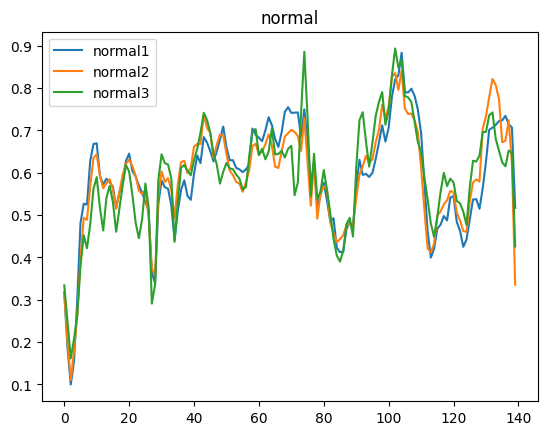

In [25]:
plt.plot(normal_train[0], label="normal1")
plt.plot(normal_train[1], label="normal2")
plt.plot(normal_train[2], label="normal3")
plt.legend()
plt.title('normal')

# 패턴이 유사한가

Text(0.5, 1.0, 'normal')

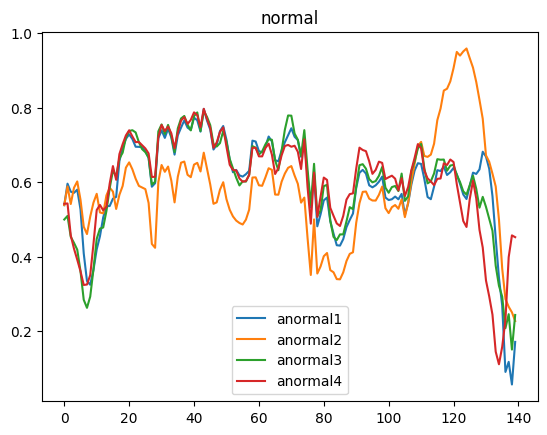

In [26]:
plt.plot(anormal_train[0], label="anormal1")
plt.plot(anormal_train[1], label="anormal2")
plt.plot(anormal_train[2], label="anormal3")
plt.plot(anormal_train[3], label="anormal4")
plt.legend()
plt.title('normal')

# 패턴이 유사한가

In [27]:
# 일반 분류모델 -> 비정상 패턴들 다 일일이 학습시켜야함
# AutoEncoder -> 정상만 완벽히 학습 -> 비정상 들어오면 -> 에러

In [28]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # 인코더(140개 특징 -> 8개의 잠재변수로 줄여나감)
        # 심전도 파형 결정짓는 - 가장 중요한 특징만 추출
        self.encoder=nn.Sequential(
            nn.Linear(140,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,8),
            nn.ReLU()            
        )

        # 디코더 (8개 => 140개)
        self.decoder=nn.Sequential(
            nn.Linear(8,16),
            nn.ReLU(),
            nn.Linear(16,32),
            nn.ReLU(),
            nn.Linear(32,64),
            nn.ReLU(),
            nn.Linear(64,140),
            # MinMaxScaler로 0~1 사이로 입력데이터 맞춰놨기 때문에, 
            # 출력값 역시 0~1로 결과물의 범위도 입력데이터와 똑같이 맞춰준다
            nn.Sigmoid()            
        )

    def forward(self, x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return decoded

In [29]:
model=AutoEncoder()
model

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=140, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=140, bias=True)
    (7): Sigmoid()
  )
)

In [30]:
# 모델이 복원한 파형과 실제 원본 파형 사이의 차이를 제곱해서 평균낸다
mseloss=nn.MSELoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)

# 예측값과 실제값 사이의 절대값 평균
def get_metrics(pred, target):
    return torch.mean(torch.abs(pred-target))

In [31]:
from tqdm.auto import tqdm
import os
from torch.utils.data import DataLoader, TensorDataset

In [32]:
save_dir='model'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
model_file=f'{save_dir}/AE.pth'

In [33]:
# AutoEncoder->입력이 정답이다.
# array -> tensor로

# AutoEncoder : 정상데이터의 특징만 학습해야함
train_tensor=torch.FloatTensor(normal_train).to(device)
# 비정상, 정상 합쳐서 -> 모델이 얼마나 이상치를 잘 걸러내는지 테스트 하려고
test_data=np.concatenate([anormal_train, normal_test], axis=0)
test_tensor=torch.FloatTensor(test_data).to(device)


In [34]:
# AutoEncoder->입력이 정답이다.
train_loader=DataLoader(TensorDataset(train_tensor, train_tensor), batch_size=5000, shuffle=True)
model=model.to(device)

In [35]:
# EarlyStopping(조기종료) : 모델이 언제 학습을 그만둘지 스스로 결정하게 만드는 장치
# 1. 매 에폭마다 오차가 줄어드는 정도 -> 최신 모델 상태
# 2. patience test : 오차 줄어들지 않으면 설정한 patience횟수만큼 지켜본다
# 3. patience 횟수 지켜봤는데 -> 오차 줄어들지 않으면 종료
epochs=100000000
patience=100

# 학습 중 가장 낮은 손실값 저장변수 -> 초기값 무한대
best_loss=float('inf')

# 성능이 개선되지 않는 횟수 카운트
trigger_times=0

# 결과 담을 딕셔너
history={'loss':[], 'val_loss':[]}

progress_bar=tqdm(range(epochs), desc='training')

for epoch in progress_bar:
    model.train()
    train_loss=0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        # 모델에 데이터를 넣어 예측값 얻는다
        output=model(batch_x)
        loss=mseloss(output, batch_y)
        # 오차를 바탕으로 각 가중치가 얼마나 변했는지 계산
        loss.backward()
        optimizer.step()
        # .item (): 텐서 -> 파이썬 숫자로 * 데이터 개수
        # 전체 손실 합
        train_loss+=loss * batch_x.size(0)

    avg_train_loss=train_loss/len(train_tensor)
        
    model.eval()
    with torch.no_grad():
        val_output=model(test_tensor)
        avg_val_loss=mseloss(val_output, test_tensor).item()


    # 결과 저장
    history['loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    # 진행바 메시지 업데이트 시킴
    progress_bar.set_postfix({'loss': f'{avg_train_loss: .4f}', 'val_loss': f'{avg_val_loss: .4f}'})

    # 이전보다 성능이 좋아졌는지 확인 -> 좋아졌으면 best_loss갱신 해나가고, state_dict를 파일에 저장시킴
    # .pth -> 모델 가중치만 저장함
    if avg_val_loss < best_loss:
        best_loss=avg_val_loss
        trigger_times=0
        torch.save(model.state_dict(), model_file)
    else:
        trigger_times+=1
        # 성능이 나아지지 않는 횟수가 100번에 도달하면 학습을 강제로 멈춘다
        if trigger_times>=patience:
            print(f"Early stopping at epoch : {epoch+1}")
            break
    

training:   0%|          | 0/100000000 [00:00<?, ?it/s]

Early stopping at epoch : 136


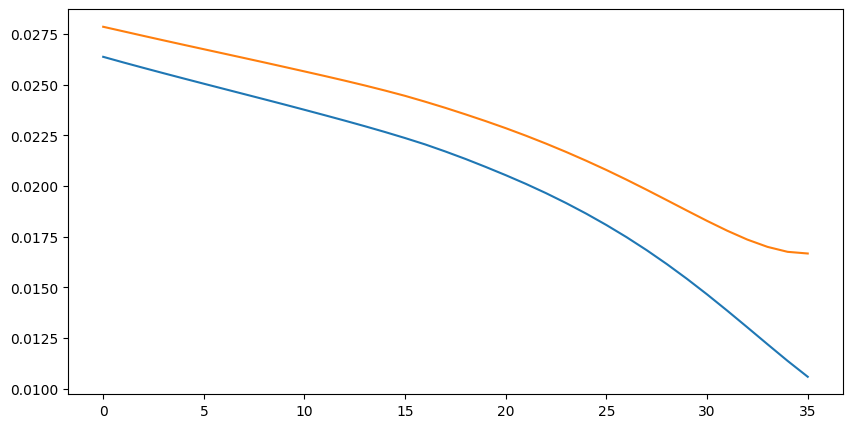

In [36]:
# 그래프 그릴 범위 설정
# 100번은 정체 구간 (patience)
# en(history['loss']) > patience 창이면 len(history['loss'])-patience
#                                거짓이면 len(history['loss']
plot_limit=len(history['loss'])-patience if len(history['loss']) > patience else len(history['loss'])

plt.figure(figsize=(10,5))

# 모델이 얼마나 정상데이터를 잘 복원했는지
# plt.plot(history['loss'][:plot_limit], label='train_loss')
# 섞어놓은 테스트 데이터에 대한 오차
# plt.plot(history['val_loss'][:plot_limit], label='test_loss')
train_loss = [t.detach().cpu().item() if torch.is_tensor(t) else t for t in history['loss'][:plot_limit]]
test_loss = [t.detach().cpu().item() if torch.is_tensor(t) else t for t in history['val_loss'][:plot_limit]]

plt.plot(train_loss, label='train_loss')
plt.plot(test_loss, label='test_loss')


In [37]:
# 저장된 파일을 불러오기 전에 그 데이터 담을 규격 만든다.
best_model=AutoEncoder().to(device)

# .pth 파일 메모리로 읽어옴
# load_state_dict : 읽어온 가중치를 빈 모델 객체의 각 레이어에 끼워서 넣는다.

# EarlyStopping을 통해 저장한 모델 -> 검증 오차가 가장 낮았던 순간
best_model.load_state_dict(torch.load(model_file, map_location=device))

best_model.eval()
print(best_model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=140, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=140, bias=True)
    (7): Sigmoid()
  )
)


/tmp/ipykernel_3897/3269349043.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(model_file, map_location=device))


In [38]:
eval_datasets=[
    ("정상 학습 데이터", normal_train),
    ("정상 테스트 데이터", normal_test),
    ("비정상 데이터", anormal_train)
]

with torch.no_grad():
    for name, data in eval_datasets:
        inputs=torch.FloatTensor(data).to(device)
        outputs=model(inputs)
        
        mse_loss=mseloss(outputs, inputs).item()
        mae_loss=torch.mean(torch.abs(outputs-inputs)).item()

        print(f"{name} | {mse_loss} | {mae_loss}")

정상 학습 데이터 | 0.005002857185900211 | 0.047459039837121964
정상 테스트 데이터 | 0.005470115225762129 | 0.049489401280879974
비정상 데이터 | 0.024468565359711647 | 0.1110788956284523


Text(0.5, 1.0, 'normal ECG')

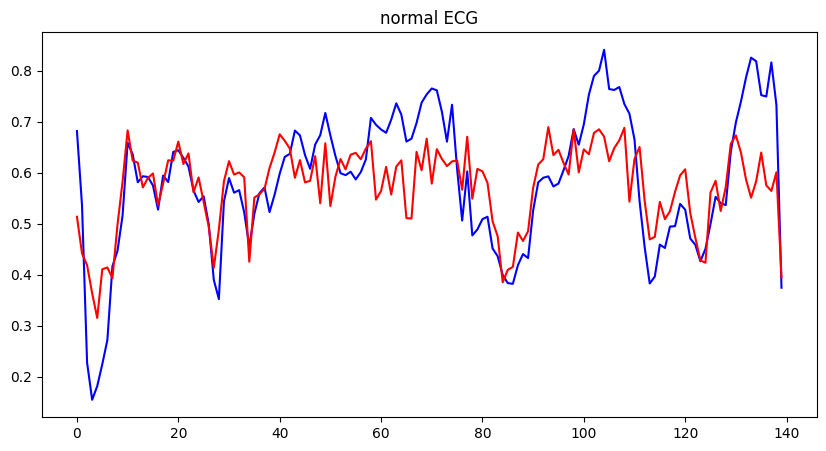

In [40]:
best_model.eval()

test_input=torch.FloatTensor(normal_test).to(device)

with torch.no_grad():
    pred=best_model(test_input)

plt.figure(figsize=(10,5))

# 새로운 정상 심전도 데이터
plt.plot(normal_test[0], 'b', label="Normal")

# 모델이 8개 잠재변수만으로 다시 그려낸 그림
plt.plot(pred[0].cpu().numpy(), 'r', label="Reconstruct")

# 그래프의 핵심 패턴 확인

plt.title('normal ECG')

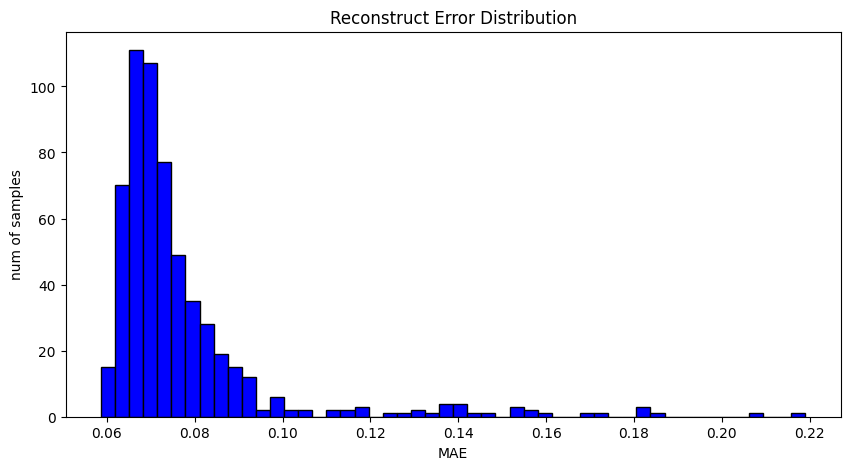

In [47]:
best_model.eval()

test_input=torch.FloatTensor(normal_test).to(device)

with torch.no_grad():
    # 예측값 얻기
    pred=best_model(test_input)
    # 각 샘플별로 오차 얼마인지 계산
    test_mae=torch.mean(torch.abs(pred-test_input), dim=1)

test_mae_numpy=test_mae.cpu().numpy()

plt.figure(figsize=(10,5))

plt.hist(test_mae_numpy, bins=50, color='blue', edgecolor='black')

plt.title('Reconstruct Error Distribution')
plt.xlabel('MAE')
plt.ylabel('num of samples')
plt.show()

# 대다수 정상데이터가 0.06~0.07 구간에 몰려있다. -> 이 정도의 오차 범위 내에서는 정상 파형을 잘 복원한다.
# 0.1 이상부터는 샘플 수가 줄어든다 -> 정상 데이터 안에서도 드물게 파형이 특이하거나 노이즈가 섞인 경우로 판단할 수 있다.

In [48]:
# 정상 데이터들이 내는 평균 오차점수 + 2 * 오차들이 평균에서 얼마나 퍼져있는지
# 정상 데이터 중 특이한 5% 제외하고, 95% 를 안전하게 포함시키고 싶다(선긋기)
threshold=np.mean(test_mae_numpy) +2 * np.std(test_mae_numpy)
print(f'임계값 : {threshold}')

# 0.117을 넘으면 비정상

임계값 : 0.11854806542396545


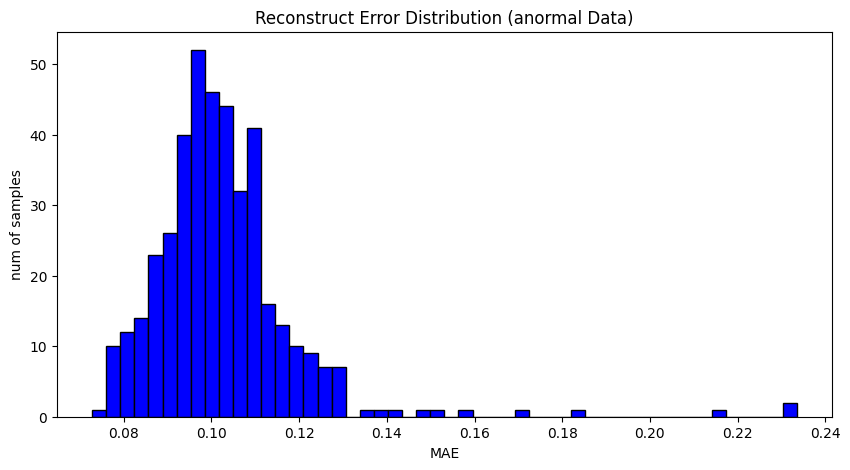

In [49]:
best_model.eval()

anormal_input=torch.FloatTensor(anormal_test).to(device)

with torch.no_grad():
    # 예측값 얻기
    pred=best_model(anormal_input)
    # 각 샘플별로 오차 얼마인지 계산
    test_mae=torch.mean(torch.abs(pred-anormal_input), dim=1)

test_mae_numpy=test_mae.cpu().numpy()

plt.figure(figsize=(10,5))

plt.hist(test_mae_numpy, bins=50, color='blue', edgecolor='black')

plt.title('Reconstruct Error Distribution (anormal Data)')
plt.xlabel('MAE')
plt.ylabel('num of samples')
plt.show()

# 대다수 정상데이터가 0.06~0.07 구간에 몰려있다. -> 이 정도의 오차 범위 내에서는 정상 파형을 잘 복원한다.
# 0.1 이상부터는 샘플 수가 줄어든다 -> 정상 데이터 안에서도 드물게 파형이 특이하거나 노이즈가 섞인 경우로 판단할 수 있다.

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(test_mae_numpy, bins=50, color='blue', edgecolor='black')

plt.hist(test_mae_numpy, bins=50, color='blue', edgecolor='black')

plt.title('Reconstruct Error Distribution (Anormal Data)')
plt.xlabel('MAE')
plt.ylabel('num of samples')
plt.show()